In [1]:
import pandas as pd 
from datetime import date, timedelta 
import datetime 
import matplotlib.pyplot as plt 
plt.style.use('fivethirtyeight') 
from statsmodels.tsa.seasonal import seasonal_decompose 
from statsmodels.graphics.tsaplots import plot_pacf 
from statsmodels.tsa.arima_model import ARIMA 
import statsmodels.api as sm 
import warnings 

In [2]:
data = pd.read_csv("adidas-quarterly-sales.csv") 
print(data) 

   Time Period  Revenue
0       2000Q1     1517
1       2000Q2     1248
2       2000Q3     1677
3       2000Q4     1393
4       2001Q1     1558
..         ...      ...
83      2020Q4     5142
84      2021Q1     5268
85      2021Q2     5077
86      2021Q3     5752
87      2021Q4     5137

[88 rows x 2 columns]


In [3]:
import plotly.express as px

figure = px.line(
    data, 
    x="Time Period",  
    y="Revenue",  
    title='Quarterly Sales Revenue of Adidas in Millions'
)

figure.show()


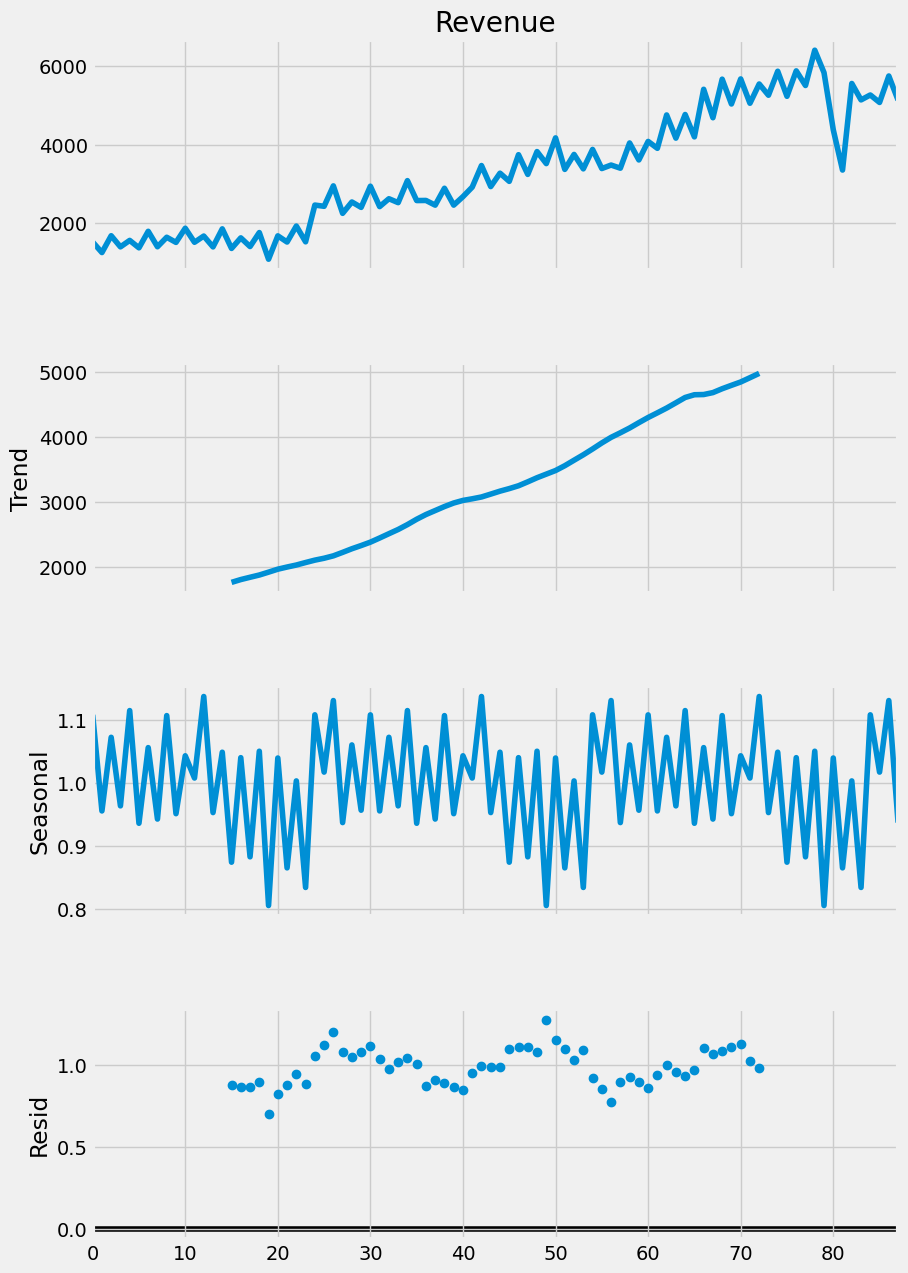

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Make sure your column name is correct — assuming it's "Revenue"
result = seasonal_decompose(data["Revenue"], model='multiplicative', period=30)

# Plot the decomposition
fig = result.plot()
fig.set_size_inches(10, 15)
plt.show()


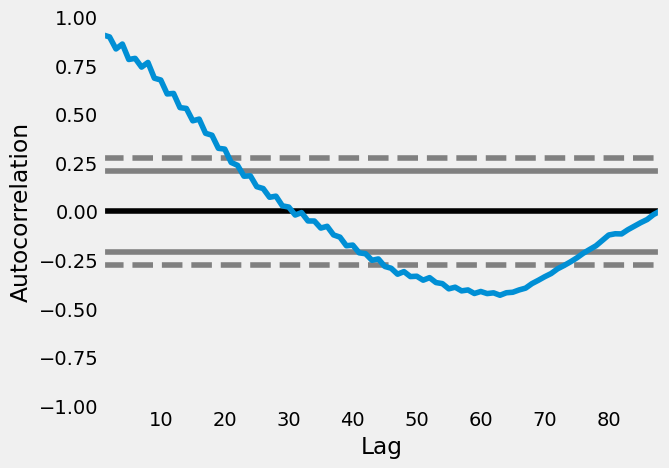

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Autocorrelation plot for the "Revenue" column
pd.plotting.autocorrelation_plot(data["Revenue"])
plt.show()


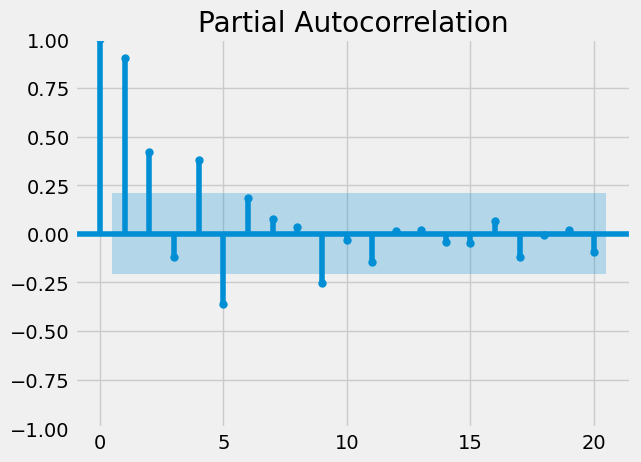

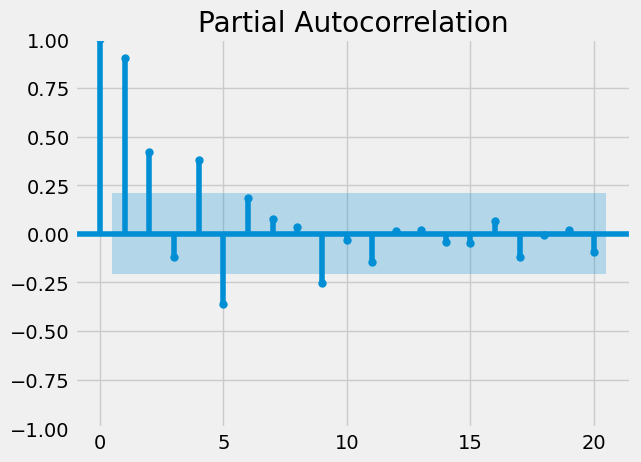

In [6]:
plot_pacf(data["Revenue"], lags = 20)

In [7]:
import statsmodels.api as sm

# Define ARIMA orders (example: you can adjust p, d, q based on model selection)
p, d, q = 1, 1, 1

# Fit SARIMA model
model = sm.tsa.statespace.SARIMAX(
    data["Revenue"],
    order=(p, d, q),
    seasonal_order=(p, d, q, 12)
)

# Fit the model
model = model.fit()

# Print the model summary
print(model.summary())


c:\Users\USER\Desktop\Business Forecasting\env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

c:\Users\USER\Desktop\Business Forecasting\env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



                                     SARIMAX Results                                      
Dep. Variable:                            Revenue   No. Observations:                   88
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -548.282
Date:                            Sat, 03 May 2025   AIC                           1106.564
Time:                                    19:30:22   BIC                           1118.152
Sample:                                         0   HQIC                          1111.191
                                             - 88                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7176      0.053     13.636      0.000       0.614       0.821
ma.L1         -0.9981      0.545   

In [8]:
predictions = model.predict(len(data), len(data)+7) 
print(predictions)

88    5821.163435
89    5422.105024
90    6515.955487
91    5899.909046
92    6275.658377
93    5667.940942
94    6646.274776
95    6105.788318
Name: predicted_mean, dtype: float64


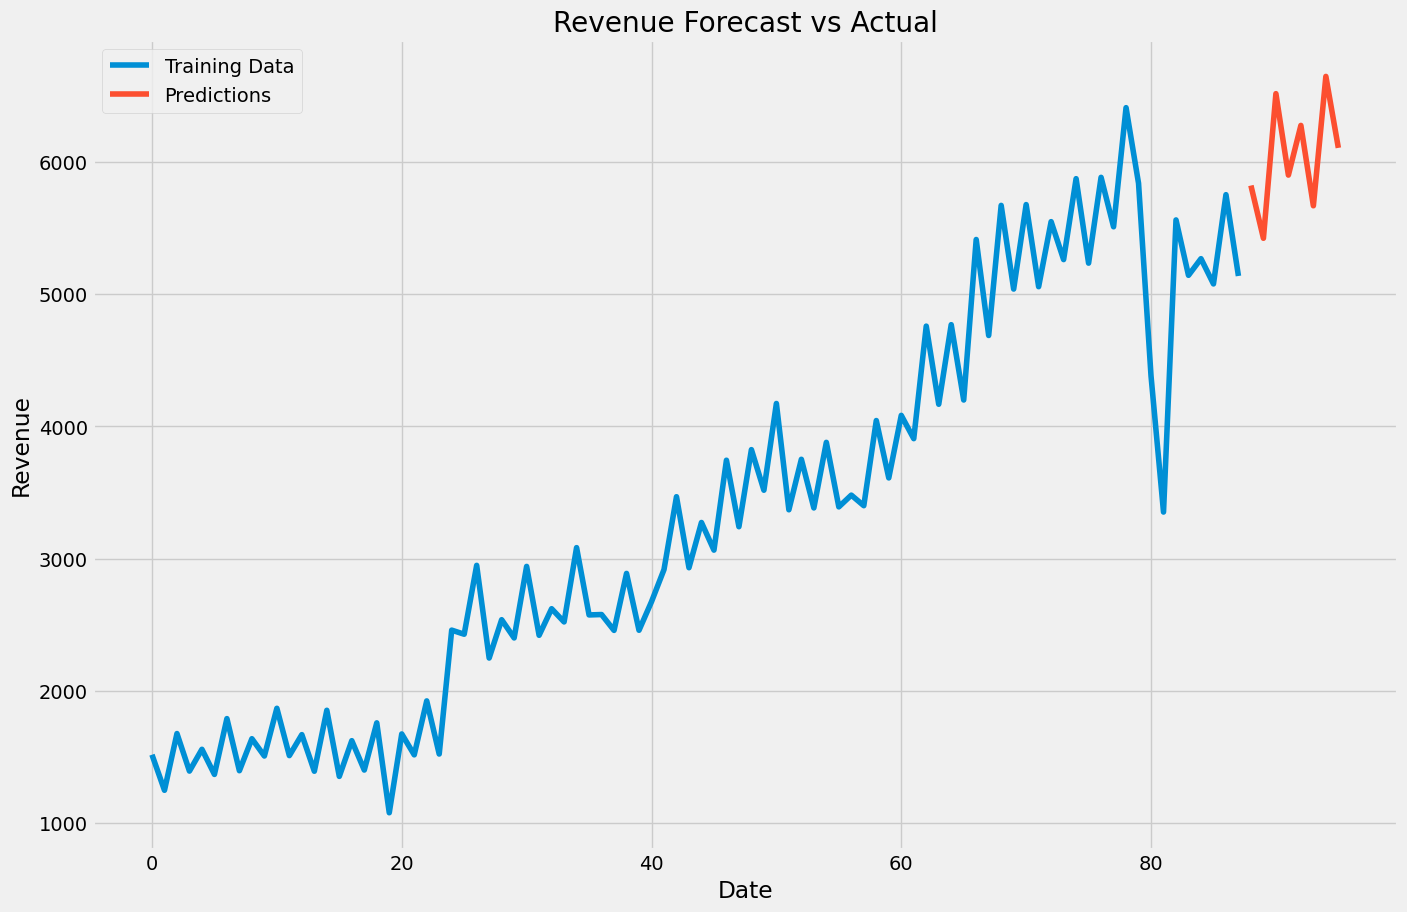

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

# Plot the training data
data["Revenue"].plot(legend=True, label="Training Data")

# Plot the predictions
predictions.plot(legend=True, label="Predictions")

plt.xlabel("Date")  # Optional: add x-axis label
plt.ylabel("Revenue")  # Optional: add y-axis label
plt.title("Revenue Forecast vs Actual")  # Optional: add title
plt.show()
